# CNN Basics: Convolutions & Pooling

---

## Learning Objectives

By the end of this notebook, you will:

- Understand the **convolution operation** as a sliding filter over an image
- Know what **filters/kernels** are and how edge detection, blur, and sharpen filters work
- Master key convolution parameters: `kernel_size`, `stride`, `padding`, `dilation`
- Compute **output dimensions** using the standard formula
- Understand **pooling** operations (max pooling, average pooling) and why they matter
- Grasp the **receptive field** concept and how it grows with depth

## Prerequisites

- **Python**: Comfortable with NumPy array operations
- **PyTorch**: Basic tensor operations (DL150)
- **Math**: Matrix multiplication, element-wise operations
- **Prior modules**: DL100 (Neural Network Fundamentals), DL150 (PyTorch Foundations)

## Table of Contents

1. [Convolution Intuition](#1.-Convolution-Intuition)
2. [Filters and Kernels](#2.-Filters-and-Kernels)
3. [Key Parameters: kernel_size, stride, padding, dilation](#3.-Key-Parameters)
4. [Output Size Formula](#4.-Output-Size-Formula)
5. [Manual Convolution with NumPy](#5.-Manual-Convolution-with-NumPy)
6. [nn.Conv2d and Feature Map Visualization](#6.-nn.Conv2d-and-Feature-Map-Visualization)
7. [Effect of Different Filters on an Image](#7.-Effect-of-Different-Filters)
8. [Pooling Operations](#8.-Pooling-Operations)
9. [Receptive Field](#9.-Receptive-Field)
10. [Common Mistakes & Debugging Tips](#10.-Common-Mistakes-&-Debugging-Tips)
11. [Exercises](#11.-Exercises)
12. [Exercise Solutions](#12.-Exercise-Solutions)

In [1]:
import sys
sys.path.insert(0, "../..")
from src.utils.seed import set_global_seed

set_global_seed(42)

import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F

print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")

PyTorch version: 2.2.2
CUDA available: False


---

## 1. Convolution Intuition

A **convolution** is a mathematical operation where a small matrix (the **kernel** or **filter**) slides across an input image, computing an element-wise multiplication and sum at each position.

**Why convolutions for images?**

- **Parameter sharing**: The same filter is applied everywhere, so we learn far fewer parameters than a fully connected layer
- **Translation equivariance**: A feature detector works regardless of where the feature appears in the image
- **Local connectivity**: Each output pixel depends only on a small local region of the input

**The sliding window process:**

```
Input (5x5)          Kernel (3x3)         Output (3x3)
+---+---+---+---+---+                     +---+---+---+
| 1 | 2 | 3 | 0 | 1 |   * [1  0 -1]  =   | ? | ? | ? |
+---+---+---+---+---+     [1  0 -1]       +---+---+---+
| 0 | 1 | 2 | 3 | 1 |     [1  0 -1]       | ? | ? | ? |
+---+---+---+---+---+                     +---+---+---+
| 1 | 0 | 1 | 2 | 0 |                     | ? | ? | ? |
+---+---+---+---+---+                     +---+---+---+
| 2 | 1 | 0 | 1 | 3 |
+---+---+---+---+---+
| 0 | 1 | 2 | 1 | 0 |
+---+---+---+---+---+
```

At each position, we compute: $\text{output}(i,j) = \sum_{m}\sum_{n} \text{input}(i+m, j+n) \cdot \text{kernel}(m, n)$

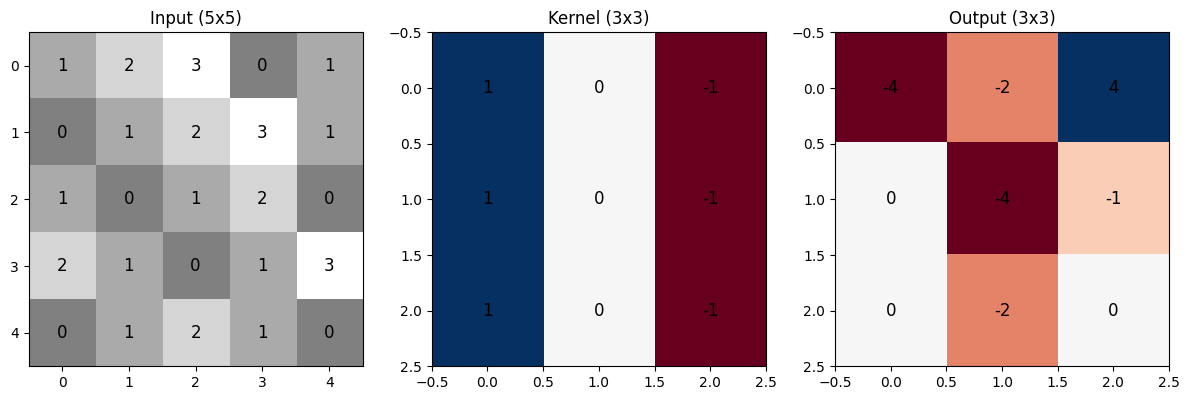

Output values:
[[-4. -2.  4.]
 [ 0. -4. -1.]
 [ 0. -2.  0.]]


In [2]:
# Visualize the sliding window concept
input_img = np.array([
    [1, 2, 3, 0, 1],
    [0, 1, 2, 3, 1],
    [1, 0, 1, 2, 0],
    [2, 1, 0, 1, 3],
    [0, 1, 2, 1, 0]
], dtype=np.float32)

kernel = np.array([
    [1,  0, -1],
    [1,  0, -1],
    [1,  0, -1]
], dtype=np.float32)

fig, axes = plt.subplots(1, 3, figsize=(12, 4))

# Show input
axes[0].imshow(input_img, cmap='gray', vmin=-3, vmax=3)
axes[0].set_title('Input (5x5)')
for i in range(5):
    for j in range(5):
        axes[0].text(j, i, f'{input_img[i, j]:.0f}', ha='center', va='center', fontsize=12)

# Show kernel
axes[1].imshow(kernel, cmap='RdBu', vmin=-1, vmax=1)
axes[1].set_title('Kernel (3x3)')
for i in range(3):
    for j in range(3):
        axes[1].text(j, i, f'{kernel[i, j]:.0f}', ha='center', va='center', fontsize=12)

# Compute convolution manually
output = np.zeros((3, 3), dtype=np.float32)
for i in range(3):
    for j in range(3):
        patch = input_img[i:i+3, j:j+3]
        output[i, j] = np.sum(patch * kernel)

# Show output
axes[2].imshow(output, cmap='RdBu')
axes[2].set_title('Output (3x3)')
for i in range(3):
    for j in range(3):
        axes[2].text(j, i, f'{output[i, j]:.0f}', ha='center', va='center', fontsize=12)

plt.tight_layout()
plt.show()

print("Output values:")
print(output)

---

## 2. Filters and Kernels

Different kernels detect different features. Here are three classic examples:

- **Edge detection**: Highlights boundaries where pixel intensity changes sharply
- **Blur (box filter)**: Averages neighboring pixels, smoothing the image
- **Sharpen**: Enhances edges by amplifying the center pixel relative to its neighbors

**Common kernels:**

| Name | Kernel | Purpose |
|------|--------|---------|
| Vertical edge | `[[1,0,-1],[1,0,-1],[1,0,-1]]` | Detect vertical edges |
| Horizontal edge | `[[1,1,1],[0,0,0],[-1,-1,-1]]` | Detect horizontal edges |
| Sobel X | `[[-1,0,1],[-2,0,2],[-1,0,1]]` | Gradient in X direction |
| Box blur | `(1/9)*[[1,1,1],[1,1,1],[1,1,1]]` | Uniform smoothing |
| Sharpen | `[[0,-1,0],[-1,5,-1],[0,-1,0]]` | Enhance edges |

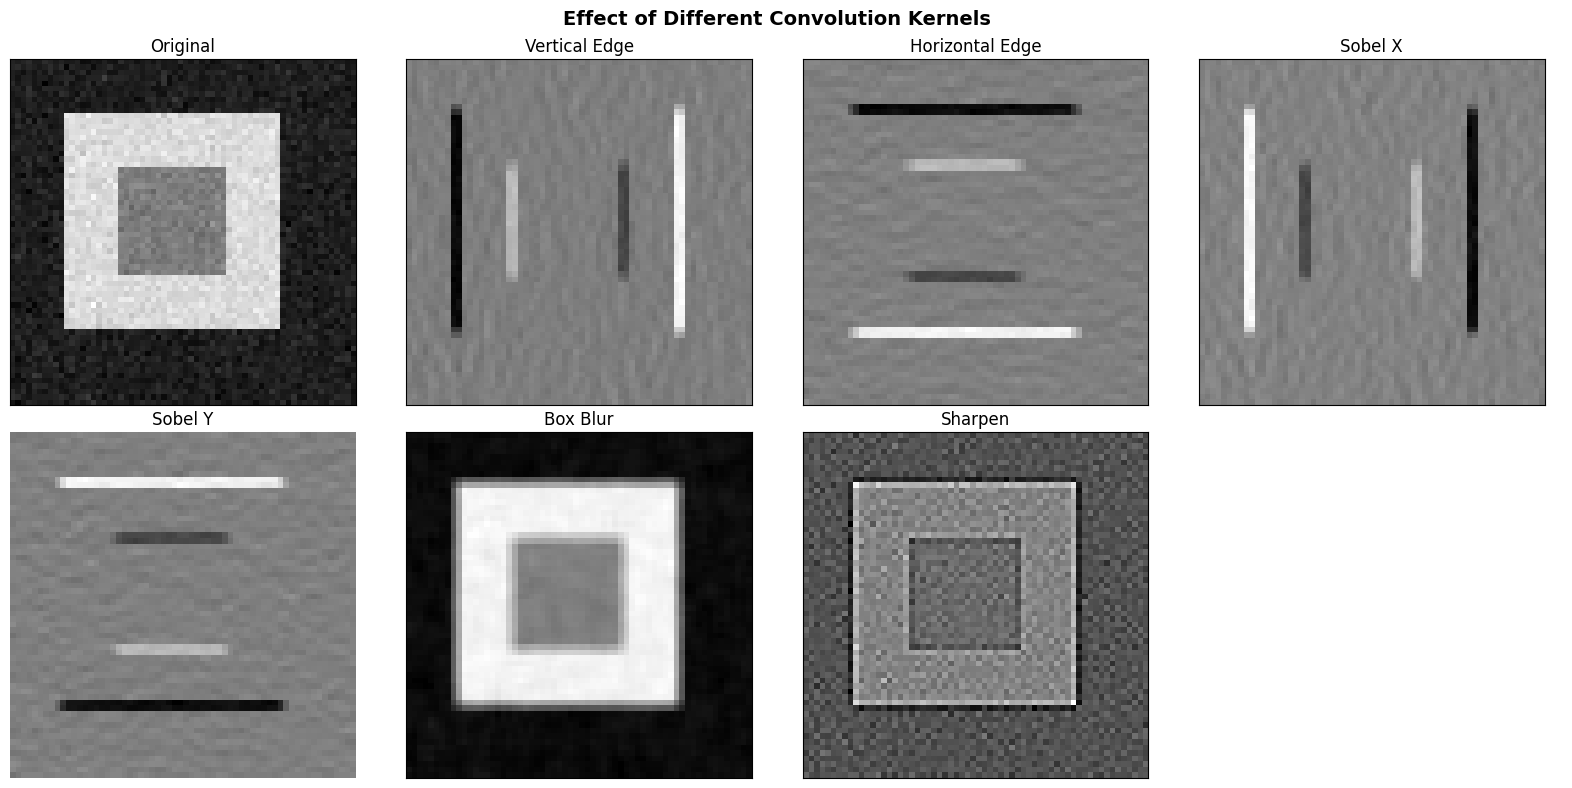

In [3]:
# Create a synthetic test image with clear edges
np.random.seed(42)
test_img = np.zeros((64, 64), dtype=np.float32)
test_img[10:50, 10:50] = 1.0          # white square
test_img[20:40, 20:40] = 0.5          # gray inner square
test_img += np.random.randn(64, 64) * 0.05  # slight noise

# Define classic kernels
kernels = {
    'Vertical Edge': np.array([[1, 0, -1], [1, 0, -1], [1, 0, -1]], dtype=np.float32),
    'Horizontal Edge': np.array([[1, 1, 1], [0, 0, 0], [-1, -1, -1]], dtype=np.float32),
    'Sobel X': np.array([[-1, 0, 1], [-2, 0, 2], [-1, 0, 1]], dtype=np.float32),
    'Sobel Y': np.array([[-1, -2, -1], [0, 0, 0], [1, 2, 1]], dtype=np.float32),
    'Box Blur': np.ones((3, 3), dtype=np.float32) / 9.0,
    'Sharpen': np.array([[0, -1, 0], [-1, 5, -1], [0, -1, 0]], dtype=np.float32),
}

fig, axes = plt.subplots(2, 4, figsize=(16, 8))

# Original image
axes[0, 0].imshow(test_img, cmap='gray')
axes[0, 0].set_title('Original')
axes[1, 0].axis('off')

# Apply each kernel
for idx, (name, k) in enumerate(kernels.items()):
    row = (idx + 1) // 4
    col = (idx + 1) % 4
    h, w = test_img.shape
    kh, kw = k.shape
    out_h, out_w = h - kh + 1, w - kw + 1
    result = np.zeros((out_h, out_w), dtype=np.float32)
    for i in range(out_h):
        for j in range(out_w):
            result[i, j] = np.sum(test_img[i:i+kh, j:j+kw] * k)
    axes[row, col].imshow(result, cmap='gray')
    axes[row, col].set_title(name)

# Clean up last empty subplot
axes[1, 3].axis('off')

for ax in axes.flat:
    ax.set_xticks([])
    ax.set_yticks([])

plt.suptitle('Effect of Different Convolution Kernels', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---

## 3. Key Parameters

### Kernel Size (`kernel_size`)
- Size of the sliding window (e.g., 3x3, 5x5, 7x7)
- Larger kernels capture more context but have more parameters
- **Common choice**: 3x3 (used in VGG, ResNet, etc.)

### Stride (`stride`)
- How many pixels the kernel moves at each step
- `stride=1`: move one pixel at a time (default)
- `stride=2`: skip every other position, **halving** the output size

### Padding (`padding`)
- Zero-pad the input borders to control output size
- `padding=0` ("valid"): no padding, output shrinks
- `padding=k//2` ("same"): output has same spatial size as input (for stride=1)

### Dilation (`dilation`)
- Spacing between kernel elements
- `dilation=1`: standard convolution
- `dilation=2`: skip one pixel between kernel elements, expanding the receptive field without adding parameters

```
Standard (dilation=1):     Dilated (dilation=2):
[X][X][X]                  [X][ ][X][ ][X]
[X][X][X]                  [ ][ ][ ][ ][ ]
[X][X][X]                  [X][ ][X][ ][X]
                           [ ][ ][ ][ ][ ]
                           [X][ ][X][ ][X]
```

In [4]:
# Demonstrate the effect of stride and padding on output size
input_tensor = torch.randn(1, 1, 8, 8)  # (batch, channels, H, W)

configs = [
    {'kernel_size': 3, 'stride': 1, 'padding': 0, 'dilation': 1},
    {'kernel_size': 3, 'stride': 1, 'padding': 1, 'dilation': 1},  # "same" padding
    {'kernel_size': 3, 'stride': 2, 'padding': 0, 'dilation': 1},
    {'kernel_size': 3, 'stride': 2, 'padding': 1, 'dilation': 1},
    {'kernel_size': 5, 'stride': 1, 'padding': 2, 'dilation': 1},
    {'kernel_size': 3, 'stride': 1, 'padding': 0, 'dilation': 2},  # dilated
]

print(f"Input shape: {input_tensor.shape} (batch=1, channels=1, H=8, W=8)")
print(f"{'Config':<50} {'Output Shape':<20}")
print("-" * 70)

for cfg in configs:
    conv = nn.Conv2d(1, 1, **cfg, bias=False)
    out = conv(input_tensor)
    desc = f"k={cfg['kernel_size']}, s={cfg['stride']}, p={cfg['padding']}, d={cfg['dilation']}"
    print(f"{desc:<50} {str(out.shape):<20}")

Input shape: torch.Size([1, 1, 8, 8]) (batch=1, channels=1, H=8, W=8)
Config                                             Output Shape        
----------------------------------------------------------------------
k=3, s=1, p=0, d=1                                 torch.Size([1, 1, 6, 6])
k=3, s=1, p=1, d=1                                 torch.Size([1, 1, 8, 8])
k=3, s=2, p=0, d=1                                 torch.Size([1, 1, 3, 3])
k=3, s=2, p=1, d=1                                 torch.Size([1, 1, 4, 4])
k=5, s=1, p=2, d=1                                 torch.Size([1, 1, 8, 8])
k=3, s=1, p=0, d=2                                 torch.Size([1, 1, 4, 4])


---

## 4. Output Size Formula

The output spatial dimension after a convolution is:

$$H_{out} = \left\lfloor\frac{H_{in} + 2p - d(k - 1) - 1}{s}\right\rfloor + 1$$

Where:
- $H_{in}$: input height (or width)
- $p$: padding
- $k$: kernel size
- $s$: stride
- $d$: dilation

**Simplified (dilation=1):**

$$H_{out} = \left\lfloor\frac{H_{in} + 2p - k}{s}\right\rfloor + 1$$

**Quick mental math rules:**
- `padding="same"` with `stride=1`: $H_{out} = H_{in}$ (set $p = k // 2$)
- `stride=2` roughly halves the dimension
- No padding with 3x3 kernel: each conv reduces size by 2

In [5]:
def compute_output_size(h_in, kernel_size, stride=1, padding=0, dilation=1):
    """Compute output spatial dimension for a convolution.
    
    Formula: H_out = floor((H_in + 2*p - d*(k-1) - 1) / s) + 1
    """
    return (h_in + 2 * padding - dilation * (kernel_size - 1) - 1) // stride + 1

# Verify the formula against PyTorch
test_cases = [
    {'h_in': 32, 'kernel_size': 3, 'stride': 1, 'padding': 0},
    {'h_in': 32, 'kernel_size': 3, 'stride': 1, 'padding': 1},
    {'h_in': 32, 'kernel_size': 5, 'stride': 2, 'padding': 2},
    {'h_in': 32, 'kernel_size': 3, 'stride': 1, 'padding': 0, 'dilation': 2},
    {'h_in': 224, 'kernel_size': 7, 'stride': 2, 'padding': 3},  # ResNet first conv
]

print(f"{'H_in':<8} {'k':<5} {'s':<5} {'p':<5} {'d':<5} {'Formula':<10} {'PyTorch':<10} {'Match?'}")
print("-" * 60)

for tc in test_cases:
    h_in = tc['h_in']
    k = tc['kernel_size']
    s = tc.get('stride', 1)
    p = tc.get('padding', 0)
    d = tc.get('dilation', 1)
    
    # Formula
    h_formula = compute_output_size(h_in, k, s, p, d)
    
    # PyTorch verification
    conv = nn.Conv2d(1, 1, kernel_size=k, stride=s, padding=p, dilation=d, bias=False)
    x = torch.randn(1, 1, h_in, h_in)
    h_torch = conv(x).shape[2]
    
    match = "Yes" if h_formula == h_torch else "NO!"
    print(f"{h_in:<8} {k:<5} {s:<5} {p:<5} {d:<5} {h_formula:<10} {h_torch:<10} {match}")

H_in     k     s     p     d     Formula    PyTorch    Match?
------------------------------------------------------------
32       3     1     0     1     30         30         Yes
32       3     1     1     1     32         32         Yes
32       5     2     2     1     16         16         Yes
32       3     1     0     2     28         28         Yes
224      7     2     3     1     112        112        Yes


---

## 5. Manual Convolution with NumPy

Let us implement 2D convolution from scratch to solidify our understanding.

In [6]:
def conv2d_numpy(image, kernel, stride=1, padding=0):
    """Perform 2D convolution using only NumPy.
    
    Args:
        image: 2D numpy array of shape (H, W)
        kernel: 2D numpy array of shape (kH, kW)
        stride: step size for the sliding window
        padding: number of zero-padding pixels on each side
    
    Returns:
        2D numpy array with convolution result
    """
    # Add padding
    if padding > 0:
        image = np.pad(image, padding, mode='constant', constant_values=0)
    
    h_in, w_in = image.shape
    kh, kw = kernel.shape
    
    # Compute output dimensions
    h_out = (h_in - kh) // stride + 1
    w_out = (w_in - kw) // stride + 1
    
    output = np.zeros((h_out, w_out), dtype=np.float32)
    
    for i in range(h_out):
        for j in range(w_out):
            row_start = i * stride
            col_start = j * stride
            patch = image[row_start:row_start+kh, col_start:col_start+kw]
            output[i, j] = np.sum(patch * kernel)
    
    return output


# Test our implementation
np.random.seed(42)
test_image = np.random.randn(8, 8).astype(np.float32)
test_kernel = np.array([[1, 0, -1], [2, 0, -2], [1, 0, -1]], dtype=np.float32)  # Sobel X

# Our implementation
our_result = conv2d_numpy(test_image, test_kernel, stride=1, padding=0)

# PyTorch reference (note: PyTorch uses cross-correlation by default,
# which is convolution with a flipped kernel. For symmetric kernels like
# Sobel, the result is the same if we flip.)
# Actually, nn.Conv2d performs cross-correlation, so we compare directly.
img_tensor = torch.from_numpy(test_image).unsqueeze(0).unsqueeze(0)  # (1, 1, 8, 8)
kern_tensor = torch.from_numpy(test_kernel).unsqueeze(0).unsqueeze(0)  # (1, 1, 3, 3)
torch_result = F.conv2d(img_tensor, kern_tensor, stride=1, padding=0).squeeze().numpy()

print("Our result shape:", our_result.shape)
print("PyTorch result shape:", torch_result.shape)
print(f"Max absolute difference: {np.max(np.abs(our_result - torch_result)):.8f}")
print("Results match:", np.allclose(our_result, torch_result, atol=1e-5))

Our result shape: (6, 6)
PyTorch result shape: (6, 6)
Max absolute difference: 0.00000095
Results match: True


In [7]:
# Test with stride and padding
our_padded = conv2d_numpy(test_image, test_kernel, stride=1, padding=1)
torch_padded = F.conv2d(img_tensor, kern_tensor, stride=1, padding=1).squeeze().numpy()

print(f"With padding=1: shape={our_padded.shape}, match={np.allclose(our_padded, torch_padded, atol=1e-5)}")

our_strided = conv2d_numpy(test_image, test_kernel, stride=2, padding=0)
torch_strided = F.conv2d(img_tensor, kern_tensor, stride=2, padding=0).squeeze().numpy()

print(f"With stride=2:  shape={our_strided.shape}, match={np.allclose(our_strided, torch_strided, atol=1e-5)}")

With padding=1: shape=(8, 8), match=True
With stride=2:  shape=(3, 3), match=True


---

## 6. nn.Conv2d and Feature Map Visualization

In practice, we use `nn.Conv2d` which handles:
- Multiple input channels (e.g., RGB = 3 channels)
- Multiple output channels (multiple filters)
- Learnable bias
- Batched inputs

**Key dimensions:**
- Input: `(batch, C_in, H, W)`
- Weight: `(C_out, C_in, kH, kW)`
- Output: `(batch, C_out, H_out, W_out)`
- Number of parameters: $C_{out} \times (C_{in} \times k_H \times k_W + 1)$ (with bias)

In [8]:
# Create a simple conv layer and examine its properties
conv = nn.Conv2d(in_channels=1, out_channels=8, kernel_size=3, stride=1, padding=1)

print(f"Weight shape: {conv.weight.shape}")  # (out_channels, in_channels, kH, kW)
print(f"Bias shape:   {conv.bias.shape}")    # (out_channels,)
print(f"Total parameters: {sum(p.numel() for p in conv.parameters())}")
print(f"  = {conv.weight.numel()} (weight) + {conv.bias.numel()} (bias)")

# Pass an input through
x = torch.randn(1, 1, 32, 32)  # batch=1, channels=1, 32x32 image
output = conv(x)
print(f"\nInput shape:  {x.shape}")
print(f"Output shape: {output.shape}")

Weight shape: torch.Size([8, 1, 3, 3])
Bias shape:   torch.Size([8])
Total parameters: 80
  = 72 (weight) + 8 (bias)

Input shape:  torch.Size([1, 1, 32, 32])
Output shape: torch.Size([1, 8, 32, 32])


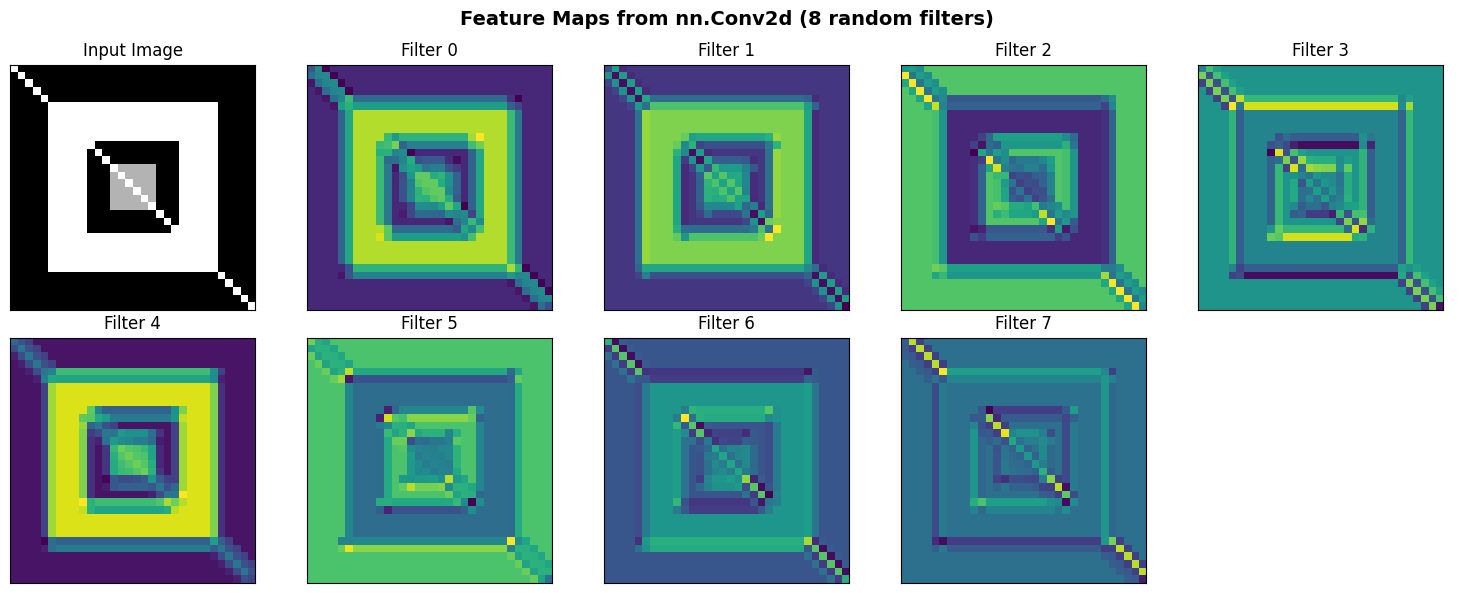

In [9]:
# Visualize the 8 feature maps produced by the conv layer
set_global_seed(42)

# Create a more interesting input image
x_np = np.zeros((32, 32), dtype=np.float32)
x_np[5:27, 5:27] = 1.0               # outer square
x_np[10:22, 10:22] = 0.0             # inner cutout
x_np[13:19, 13:19] = 0.7             # small inner square
# Add a diagonal line
for i in range(32):
    if 0 <= i < 32:
        x_np[i, i] = 1.0

x_tensor = torch.from_numpy(x_np).unsqueeze(0).unsqueeze(0)  # (1, 1, 32, 32)

conv = nn.Conv2d(1, 8, kernel_size=3, padding=1)
with torch.no_grad():
    feature_maps = conv(x_tensor)

fig, axes = plt.subplots(2, 5, figsize=(15, 6))

# Original image
axes[0, 0].imshow(x_np, cmap='gray')
axes[0, 0].set_title('Input Image')

# 8 feature maps + 1 empty slot
for i in range(8):
    row = (i + 1) // 5
    col = (i + 1) % 5
    fm = feature_maps[0, i].detach().numpy()
    axes[row, col].imshow(fm, cmap='viridis')
    axes[row, col].set_title(f'Filter {i}')

# Hide last empty subplot
axes[1, 4].axis('off')

for ax in axes.flat:
    ax.set_xticks([])
    ax.set_yticks([])

plt.suptitle('Feature Maps from nn.Conv2d (8 random filters)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---

## 7. Effect of Different Filters

Let us manually set `nn.Conv2d` weights to known kernels and see what each one does.

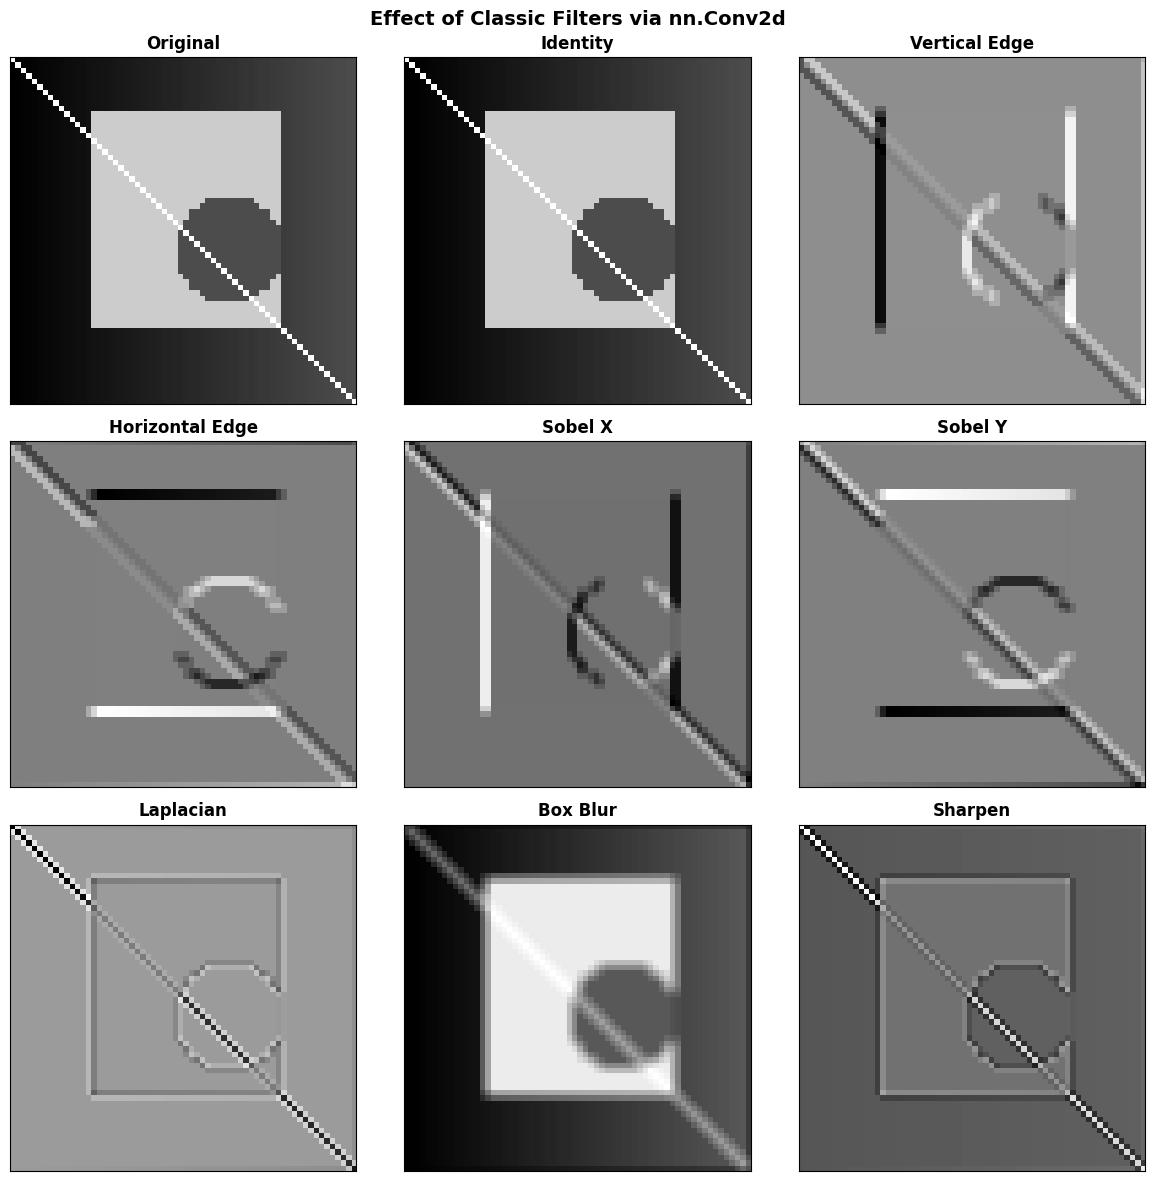

In [10]:
# Create a richer test image with gradients and shapes
np.random.seed(42)
img = np.zeros((64, 64), dtype=np.float32)
# Horizontal gradient
img += np.linspace(0, 0.3, 64).reshape(1, -1)
# Rectangle
img[10:50, 15:50] = 0.8
# Circle
yy, xx = np.ogrid[:64, :64]
circle_mask = ((yy - 35)**2 + (xx - 40)**2) < 10**2
img[circle_mask] = 0.3
# Diagonal line
for i in range(64):
    img[i, min(i, 63)] = 1.0

named_kernels = {
    'Identity': np.array([[0,0,0],[0,1,0],[0,0,0]], dtype=np.float32),
    'Vertical Edge': np.array([[1,0,-1],[1,0,-1],[1,0,-1]], dtype=np.float32),
    'Horizontal Edge': np.array([[1,1,1],[0,0,0],[-1,-1,-1]], dtype=np.float32),
    'Sobel X': np.array([[-1,0,1],[-2,0,2],[-1,0,1]], dtype=np.float32),
    'Sobel Y': np.array([[-1,-2,-1],[0,0,0],[1,2,1]], dtype=np.float32),
    'Laplacian': np.array([[0,1,0],[1,-4,1],[0,1,0]], dtype=np.float32),
    'Box Blur': np.ones((3,3), dtype=np.float32) / 9.0,
    'Sharpen': np.array([[0,-1,0],[-1,5,-1],[0,-1,0]], dtype=np.float32),
}

img_tensor = torch.from_numpy(img).unsqueeze(0).unsqueeze(0)

fig, axes = plt.subplots(3, 3, figsize=(12, 12))
axes[0, 0].imshow(img, cmap='gray')
axes[0, 0].set_title('Original', fontweight='bold')

for idx, (name, kernel) in enumerate(named_kernels.items()):
    row = (idx + 1) // 3
    col = (idx + 1) % 3
    
    # Set Conv2d weights manually
    conv_layer = nn.Conv2d(1, 1, kernel_size=3, padding=1, bias=False)
    with torch.no_grad():
        conv_layer.weight.copy_(torch.from_numpy(kernel).unsqueeze(0).unsqueeze(0))
    
    with torch.no_grad():
        result = conv_layer(img_tensor).squeeze().numpy()
    
    axes[row, col].imshow(result, cmap='gray')
    axes[row, col].set_title(name, fontweight='bold')

for ax in axes.flat:
    ax.set_xticks([])
    ax.set_yticks([])

plt.suptitle('Effect of Classic Filters via nn.Conv2d', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---

## 8. Pooling Operations

**Pooling** reduces the spatial dimensions of feature maps, providing:

- **Dimensionality reduction**: Fewer parameters and computations in subsequent layers
- **Translation invariance**: Small shifts in input do not change the output much
- **Larger receptive field**: Each output neuron "sees" more of the input

### Max Pooling
Takes the **maximum value** in each window. Preserves the strongest activation.

### Average Pooling
Takes the **mean value** in each window. Smoother, less aggressive downsampling.

**Output size formula** (same as convolution with $d=1$):

$$H_{out} = \left\lfloor\frac{H_{in} + 2p - k}{s}\right\rfloor + 1$$

**Common configurations:**
- `MaxPool2d(kernel_size=2, stride=2)` -- halves spatial dimensions
- `AdaptiveAvgPool2d(1)` -- global average pooling to 1x1

In [11]:
# Demonstrate max pooling and average pooling
set_global_seed(42)

# Create a small feature map to clearly see the effect
feature_map = torch.tensor([
    [1, 3, 2, 4],
    [5, 6, 7, 8],
    [3, 2, 1, 0],
    [9, 4, 5, 3]
], dtype=torch.float32).unsqueeze(0).unsqueeze(0)  # (1, 1, 4, 4)

max_pool = nn.MaxPool2d(kernel_size=2, stride=2)
avg_pool = nn.AvgPool2d(kernel_size=2, stride=2)

max_result = max_pool(feature_map)
avg_result = avg_pool(feature_map)

print("Input (4x4):")
print(feature_map.squeeze().numpy())
print(f"\nMax Pooling (2x2, stride=2) -> {max_result.shape[-2]}x{max_result.shape[-1]}:")
print(max_result.squeeze().numpy())
print(f"\nAvg Pooling (2x2, stride=2) -> {avg_result.shape[-2]}x{avg_result.shape[-1]}:")
print(avg_result.squeeze().numpy())

Input (4x4):
[[1. 3. 2. 4.]
 [5. 6. 7. 8.]
 [3. 2. 1. 0.]
 [9. 4. 5. 3.]]

Max Pooling (2x2, stride=2) -> 2x2:
[[6. 8.]
 [9. 5.]]

Avg Pooling (2x2, stride=2) -> 2x2:
[[3.75 5.25]
 [4.5  2.25]]


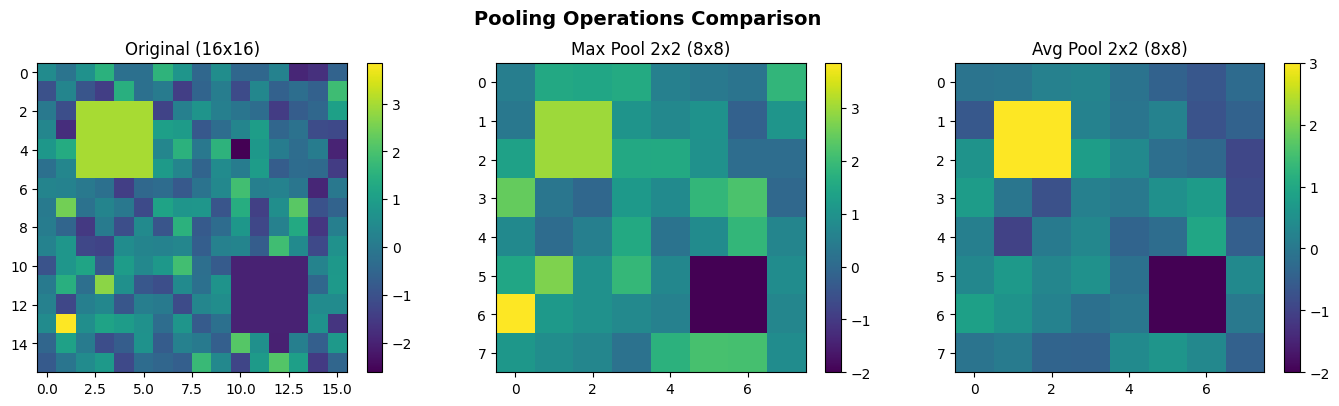

In [12]:
# Visualize pooling on a real-ish feature map
np.random.seed(42)
large_fm = np.random.randn(16, 16).astype(np.float32)
# Add some structure
large_fm[2:6, 2:6] = 3.0
large_fm[10:14, 10:14] = -2.0

fm_tensor = torch.from_numpy(large_fm).unsqueeze(0).unsqueeze(0)

max_out = nn.MaxPool2d(2, 2)(fm_tensor).squeeze().numpy()
avg_out = nn.AvgPool2d(2, 2)(fm_tensor).squeeze().numpy()

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

im0 = axes[0].imshow(large_fm, cmap='viridis')
axes[0].set_title(f'Original ({large_fm.shape[0]}x{large_fm.shape[1]})')
plt.colorbar(im0, ax=axes[0], fraction=0.046)

im1 = axes[1].imshow(max_out, cmap='viridis')
axes[1].set_title(f'Max Pool 2x2 ({max_out.shape[0]}x{max_out.shape[1]})')
plt.colorbar(im1, ax=axes[1], fraction=0.046)

im2 = axes[2].imshow(avg_out, cmap='viridis')
axes[2].set_title(f'Avg Pool 2x2 ({avg_out.shape[0]}x{avg_out.shape[1]})')
plt.colorbar(im2, ax=axes[2], fraction=0.046)

plt.suptitle('Pooling Operations Comparison', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [13]:
# Global Average Pooling (commonly used before the final FC layer)
# Reduces any spatial size to 1x1
gap = nn.AdaptiveAvgPool2d(1)

x = torch.randn(1, 64, 7, 7)  # typical feature map before classifier
out = gap(x)
print(f"Input shape:  {x.shape}")
print(f"After GAP:    {out.shape}")
print(f"After squeeze: {out.squeeze().shape}  (ready for FC layer)")

Input shape:  torch.Size([1, 64, 7, 7])
After GAP:    torch.Size([1, 64, 1, 1])
After squeeze: torch.Size([64])  (ready for FC layer)


---

## 9. Receptive Field

The **receptive field** of a neuron is the region of the original input that influences that neuron's output.

**Key insights:**
- A single 3x3 conv layer: receptive field = 3x3
- Two stacked 3x3 conv layers: receptive field = 5x5
- Three stacked 3x3 conv layers: receptive field = 7x7

**This is why stacking small filters is preferred over one large filter:**
- Two 3x3 convs have the same receptive field as one 5x5 conv
- But fewer parameters: $2 \times (3 \times 3) = 18$ vs $5 \times 5 = 25$
- Plus two non-linearities instead of one (more expressive)

**Receptive field formula for stacked layers (stride=1, no dilation):**

$$RF_L = RF_{L-1} + (k_L - 1) \times \prod_{i=1}^{L-1} s_i$$

Where $RF_1 = k_1$ (first layer), and $s_i$ is the stride of layer $i$.

**Pooling and stride > 1 grow the receptive field faster** because they multiply the contribution of subsequent layers.

In [14]:
def compute_receptive_field(layers):
    """Compute receptive field for a stack of conv/pool layers.
    
    Args:
        layers: list of dicts with 'kernel_size' and 'stride' keys
    
    Returns:
        Receptive field size
    """
    rf = 1  # start with a single pixel
    stride_product = 1
    
    for layer in layers:
        k = layer['kernel_size']
        s = layer['stride']
        rf = rf + (k - 1) * stride_product
        stride_product *= s
    
    return rf

# Example: stacking 3x3 convolutions
print("Stacking 3x3 convolutions (stride=1):")
for n_layers in range(1, 6):
    layers = [{'kernel_size': 3, 'stride': 1}] * n_layers
    rf = compute_receptive_field(layers)
    params = n_layers * 9  # ignoring channels
    print(f"  {n_layers} layer(s): RF = {rf}x{rf}, params ~ {params}")

print("\nEquivalent single-layer convolutions:")
for k in [3, 5, 7, 9, 11]:
    print(f"  1 layer k={k}: RF = {k}x{k}, params = {k*k}")

print("\nWith pooling (stride=2):")
# Conv3x3(s1) -> Pool2x2(s2) -> Conv3x3(s1) -> Pool2x2(s2)
layers_with_pool = [
    {'kernel_size': 3, 'stride': 1},
    {'kernel_size': 2, 'stride': 2},  # max pool
    {'kernel_size': 3, 'stride': 1},
    {'kernel_size': 2, 'stride': 2},  # max pool
]
for i in range(1, len(layers_with_pool) + 1):
    rf = compute_receptive_field(layers_with_pool[:i])
    name = ['Conv3x3', 'Pool2x2', 'Conv3x3', 'Pool2x2'][i-1]
    print(f"  After {name} (layer {i}): RF = {rf}x{rf}")

Stacking 3x3 convolutions (stride=1):
  1 layer(s): RF = 3x3, params ~ 9
  2 layer(s): RF = 5x5, params ~ 18
  3 layer(s): RF = 7x7, params ~ 27
  4 layer(s): RF = 9x9, params ~ 36
  5 layer(s): RF = 11x11, params ~ 45

Equivalent single-layer convolutions:
  1 layer k=3: RF = 3x3, params = 9
  1 layer k=5: RF = 5x5, params = 25
  1 layer k=7: RF = 7x7, params = 49
  1 layer k=9: RF = 9x9, params = 81
  1 layer k=11: RF = 11x11, params = 121

With pooling (stride=2):
  After Conv3x3 (layer 1): RF = 3x3
  After Pool2x2 (layer 2): RF = 4x4
  After Conv3x3 (layer 3): RF = 8x8
  After Pool2x2 (layer 4): RF = 10x10


---

## 10. Common Mistakes & Debugging Tips

### Shape Mismatches
- **Always track shapes** through your network. Print `x.shape` after each layer during debugging.
- Remember: PyTorch uses `(batch, channels, height, width)` -- **NCHW** format.
- NumPy/PIL images are typically `(height, width, channels)` -- **HWC** format.

### Output Size Errors
- If you get a "size mismatch" error at the Flatten-to-FC boundary, compute the actual flattened size:
  ```python
  # Debug trick: pass a dummy input through conv layers
  dummy = torch.randn(1, 3, 32, 32)
  out = self.features(dummy)
  print(out.shape)  # Use this to set FC input size
  ```

### Forgetting Channel Dimension
- `nn.Conv2d` expects `(batch, channels, H, W)`, **not** `(batch, H, W)`
- Use `.unsqueeze(1)` to add a channel dim to grayscale images

### Padding for "Same" Output
- For kernel size $k$ (odd) with stride 1: use `padding = k // 2`
- PyTorch also supports `padding='same'` (since v1.9), but only for stride=1

### Confusing Convolution vs Cross-Correlation
- PyTorch `nn.Conv2d` actually performs **cross-correlation** (no kernel flip)
- This is standard in deep learning and does not affect learning

### Pooling Removes Information
- Max pooling is **not invertible** -- you lose spatial precision
- For tasks requiring precise localization (e.g., segmentation), consider strided convolutions or skip connections

---

## 11. Exercises

### Exercise 1: Calculate Output Dimensions by Hand

For each configuration below, compute the output height and width **by hand** using the formula:

$$H_{out} = \left\lfloor\frac{H_{in} + 2p - d(k - 1) - 1}{s}\right\rfloor + 1$$

Then verify with code.

| # | Input Size | kernel_size | stride | padding | dilation | Expected H_out |
|---|-----------|-------------|--------|---------|----------|---------------|
| a | 28x28     | 5           | 1      | 0       | 1        | ?             |
| b | 28x28     | 5           | 1      | 2       | 1        | ?             |
| c | 32x32     | 3           | 2      | 1       | 1        | ?             |
| d | 224x224   | 7           | 2      | 3       | 1        | ?             |
| e | 16x16     | 3           | 1      | 2       | 2        | ?             |

### Exercise 2: Custom Edge Detector

Create a 3x3 kernel that detects **diagonal edges** (top-left to bottom-right). Apply it to the test image and visualize the result.

### Exercise 3: Pooling Comparison

Create a 16x16 feature map with specific patterns (e.g., a bright corner, a gradient). Apply `MaxPool2d(2)` and `AvgPool2d(2)` and explain when each is preferable.

In [15]:
# Exercise space -- try the exercises here before looking at solutions

# Exercise 1: Verify your hand calculations
# YOUR CODE HERE


# Exercise 2: Diagonal edge detector
# YOUR CODE HERE


# Exercise 3: Pooling comparison
# YOUR CODE HERE


---

## 12. Exercise Solutions

In [16]:
# --- Exercise 1 Solution ---
# Hand calculations:
# a) H_out = floor((28 + 0 - 5) / 1) + 1 = floor(23) + 1 = 24
# b) H_out = floor((28 + 4 - 5) / 1) + 1 = floor(27) + 1 = 28  (same padding!)
# c) H_out = floor((32 + 2 - 3) / 2) + 1 = floor(31/2) + 1 = 15 + 1 = 16
# d) H_out = floor((224 + 6 - 7) / 2) + 1 = floor(223/2) + 1 = 111 + 1 = 112
# e) H_out = floor((16 + 4 - 2*(3-1) - 1) / 1) + 1 = floor((16+4-4-1)/1) + 1 = 15 + 1 = 16

exercises = [
    {'label': 'a', 'h_in': 28,  'k': 5, 's': 1, 'p': 0, 'd': 1, 'expected': 24},
    {'label': 'b', 'h_in': 28,  'k': 5, 's': 1, 'p': 2, 'd': 1, 'expected': 28},
    {'label': 'c', 'h_in': 32,  'k': 3, 's': 2, 'p': 1, 'd': 1, 'expected': 16},
    {'label': 'd', 'h_in': 224, 'k': 7, 's': 2, 'p': 3, 'd': 1, 'expected': 112},
    {'label': 'e', 'h_in': 16,  'k': 3, 's': 1, 'p': 2, 'd': 2, 'expected': 16},
]

for ex in exercises:
    result = compute_output_size(ex['h_in'], ex['k'], ex['s'], ex['p'], ex['d'])
    
    # Verify with PyTorch
    conv = nn.Conv2d(1, 1, kernel_size=ex['k'], stride=ex['s'],
                     padding=ex['p'], dilation=ex['d'], bias=False)
    x = torch.randn(1, 1, ex['h_in'], ex['h_in'])
    pytorch_result = conv(x).shape[2]
    
    status = "PASS" if result == ex['expected'] == pytorch_result else "FAIL"
    print(f"  {ex['label']}) Formula={result}, Expected={ex['expected']}, "
          f"PyTorch={pytorch_result} [{status}]")

  a) Formula=24, Expected=24, PyTorch=24 [PASS]
  b) Formula=28, Expected=28, PyTorch=28 [PASS]
  c) Formula=16, Expected=16, PyTorch=16 [PASS]
  d) Formula=112, Expected=112, PyTorch=112 [PASS]
  e) Formula=16, Expected=16, PyTorch=16 [PASS]


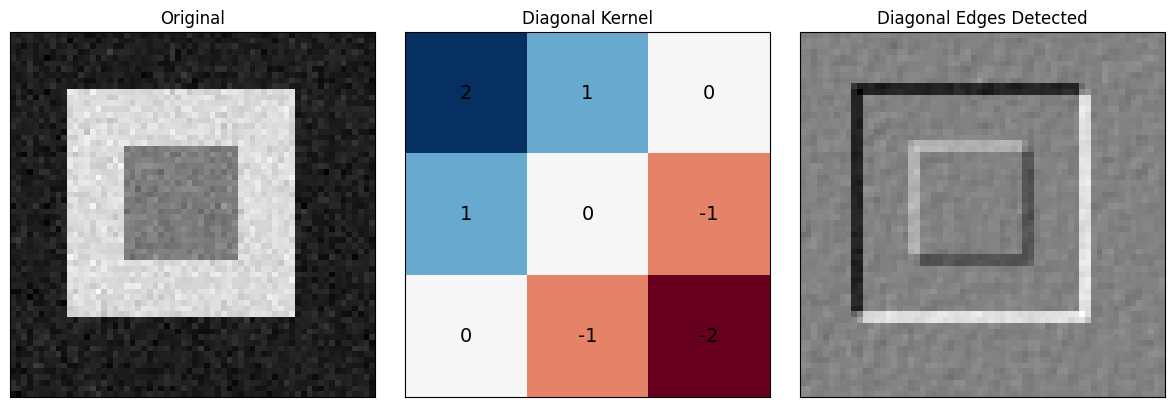

In [17]:
# --- Exercise 2 Solution ---
# Diagonal edge detector (top-left to bottom-right)
diagonal_kernel = np.array([
    [ 2,  1,  0],
    [ 1,  0, -1],
    [ 0, -1, -2]
], dtype=np.float32)

# Apply to test image
diag_result = conv2d_numpy(test_img, diagonal_kernel, padding=1)

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
axes[0].imshow(test_img, cmap='gray')
axes[0].set_title('Original')
axes[1].imshow(diagonal_kernel, cmap='RdBu', vmin=-2, vmax=2)
axes[1].set_title('Diagonal Kernel')
for i in range(3):
    for j in range(3):
        axes[1].text(j, i, f'{diagonal_kernel[i,j]:.0f}', ha='center', va='center', fontsize=14)
axes[2].imshow(diag_result, cmap='gray')
axes[2].set_title('Diagonal Edges Detected')

for ax in axes:
    ax.set_xticks([])
    ax.set_yticks([])
plt.tight_layout()
plt.show()

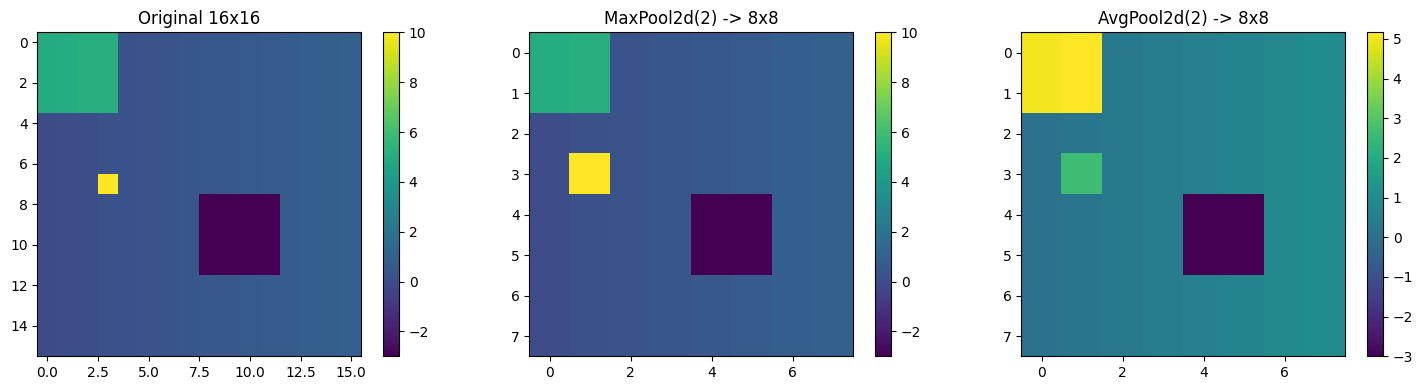

Key observations:
- MaxPool preserves the spike at (7,3) -> value 10.0 appears in output
- AvgPool dilutes the spike (averaged with neighbors)
- MaxPool is better for detecting if a feature EXISTS anywhere in the window
- AvgPool is better when you want smooth, aggregate information


In [18]:
# --- Exercise 3 Solution ---
np.random.seed(42)

# Create structured 16x16 feature map
fm = np.zeros((16, 16), dtype=np.float32)
fm[0:4, 0:4] = 5.0           # bright corner
fm += np.linspace(0, 1, 16).reshape(1, -1)  # horizontal gradient
fm[8:12, 8:12] = -3.0        # dark patch
# Sprinkle some noise
fm[7, 3] = 10.0              # single spike

fm_tensor = torch.from_numpy(fm).unsqueeze(0).unsqueeze(0)
max_out = nn.MaxPool2d(2, 2)(fm_tensor).squeeze().numpy()
avg_out = nn.AvgPool2d(2, 2)(fm_tensor).squeeze().numpy()

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, data, title in zip(axes, [fm, max_out, avg_out],
                            ['Original 16x16', 'MaxPool2d(2) -> 8x8', 'AvgPool2d(2) -> 8x8']):
    im = ax.imshow(data, cmap='viridis')
    ax.set_title(title)
    plt.colorbar(im, ax=ax, fraction=0.046)

plt.tight_layout()
plt.show()

print("Key observations:")
print("- MaxPool preserves the spike at (7,3) -> value 10.0 appears in output")
print("- AvgPool dilutes the spike (averaged with neighbors)")
print("- MaxPool is better for detecting if a feature EXISTS anywhere in the window")
print("- AvgPool is better when you want smooth, aggregate information")